# ValuSense — Notebook 03 Consolidé
## EDA + Feature Engineering + Rebalancing (Version Corrigée)

### Problèmes identifiés dans la version précédente

| # | Problème | Impact | Correction |
|---|----------|--------|------------|
| 1 | **Ordre du pipeline inversé** : la régénération des 2400 échantillons (DDM/MtM/Relative) a été faite mais le notebook EDA a rechargé le Tier 3 original (12 859 lignes), pas le dataset balanced (15 259) | Les 2400 nouveaux échantillons n'ont jamais été enrichis ni utilisés pour le ML | Charger `labeled_valuation_dataset_balanced.csv` dès le départ |
| 2 | **2 features entièrement NaN** : `credit_spread_ig` et `credit_spread_hy` (25 718 NaN sur 25 718 total) — les colonnes FRED n'ont pas été trouvées | 2 colonnes inutiles qui polluent le dataset | Les supprimer ou corriger le mapping des colonnes FRED |
| 3 | **Violations domaine** : Bond→Binomial-Tree (171 lignes), Currency→DCF (231 lignes) | Échantillons incohérents dans le training set | Corriger les labels ou supprimer ces lignes |
| 4 | **equity_historical_prices corrompu** : erreur `'kind'` au chargement | Aucune feature de volatilité historique (vol_30d, vol_90d, vol_of_vol) | Reconstruire ou ignorer (les features structurelles suffisent) |
| 5 | **class_weight extrême** : poids de 54-68x pour DDM/MtM/Relative (15-19 vrais échantillons) | Le modèle sur-compense pour des classes quasi-absentes | Utiliser le dataset balanced avec 800+ par classe |


---
## 0. Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings("ignore")

DATA_ROOT = Path("data_valuation_project")
RAW       = DATA_ROOT / "raw"
PROCESSED = DATA_ROOT / "processed"
FIG_DIR   = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 13, "figure.dpi": 120})
sns.set_style("whitegrid")
print("Setup OK")

Setup OK


---
## 1. Charger le Dataset Balanced (Post-Régénération)

**Critique** : on charge `labeled_valuation_dataset_balanced.csv` (15 259 lignes)
qui inclut les 2 400 échantillons ciblés pour DDM, Mark-to-Market et Relative.


In [2]:
# ── Charger le bon dataset ─────────────────────────────────────
balanced_path = PROCESSED / "labeled_valuation_dataset_balanced.csv"
tier3_path    = PROCESSED / "labeled_valuation_dataset_tier3.csv"

if balanced_path.exists():
    df = pd.read_csv(balanced_path)
    source_name = "Balanced (post-regeneration)"
elif tier3_path.exists():
    df = pd.read_csv(tier3_path)
    source_name = "Tier 3 (ATTENTION: non balanced)"
    print("⚠️  ATTENTION : labeled_valuation_dataset_balanced.csv introuvable")
    print("   Executez d'abord la regeneration ciblee (notebook 03b sections 5-6)")
else:
    raise FileNotFoundError("Aucun dataset trouve dans processed/")

print(f"Dataset : {source_name}")
print(f"Shape   : {df.shape}")
print(f"\nDistribution de la cible :")
counts = df["recommended_method"].value_counts()
for method, count in counts.items():
    pct = count / len(df) * 100
    flag = " ⚠️" if count < 50 else ""
    print(f"  {method:20s} : {count:6,} ({pct:5.1f}%){flag}")

ratio = counts.max() / counts.min()
print(f"\nRatio d'imbalance : {ratio:.1f}:1")

if ratio > 10:
    print("⚠️  Ratio encore trop eleve — les 3 classes regenerees sont-elles bien presentes ?")
elif ratio <= 6:
    print("✅ Ratio acceptable pour class_weight='balanced'")

Dataset : Balanced (post-regeneration)
Shape   : (15259, 15)

Distribution de la cible :
  DCF                  :  4,440 ( 29.1%)
  Black-Scholes        :  1,800 ( 11.8%)
  Cost-of-Carry        :  1,553 ( 10.2%)
  Credit-Model         :  1,545 ( 10.1%)
  Forward-Pricing      :  1,183 (  7.8%)
  Monte-Carlo          :  1,161 (  7.6%)
  Binomial-Tree        :  1,113 (  7.3%)
  DDM                  :    824 (  5.4%)
  Mark-to-Market       :    822 (  5.4%)
  Relative             :    818 (  5.4%)

Ratio d'imbalance : 5.4:1
✅ Ratio acceptable pour class_weight='balanced'


---
## 2. Correction des Violations de Domaine

Le diagnostic a révélé 2 violations :
- **Bond → Binomial-Tree** (171 lignes) : les obligations ne sont pas des options
- **Currency → DCF** (231 lignes) : les devises utilisent Forward-Pricing, pas DCF

On corrige les labels plutôt que de supprimer les lignes (préserver le volume).


In [3]:
n_before = len(df)

# ── Correction 1 : Bond + Binomial-Tree → DCF ────────────────
mask_bond_bt = (df["asset_class"] == "Bond") & (df["recommended_method"] == "Binomial-Tree")
n_fix1 = mask_bond_bt.sum()
if n_fix1 > 0:
    # Les convertible bonds pourraient justifier Binomial-Tree, mais dans notre
    # scope (Hull Ch. 6), les bonds utilisent DCF ou Credit-Model
    # On route vers Credit-Model si has_credit_risk=1, sinon DCF
    credit_mask = mask_bond_bt & (df["has_credit_risk"] == 1)
    non_credit  = mask_bond_bt & (df["has_credit_risk"] == 0)
    df.loc[credit_mask, "recommended_method"] = "Credit-Model"
    df.loc[non_credit, "recommended_method"] = "DCF"
    print(f"Fix 1 : Bond+Binomial-Tree → {credit_mask.sum()} vers Credit-Model, {non_credit.sum()} vers DCF")

# ── Correction 2 : Currency + DCF → Forward-Pricing ──────────
mask_cur_dcf = (df["asset_class"] == "Currency") & (df["recommended_method"] == "DCF")
n_fix2 = mask_cur_dcf.sum()
if n_fix2 > 0:
    df.loc[mask_cur_dcf, "recommended_method"] = "Forward-Pricing"
    print(f"Fix 2 : Currency+DCF → {n_fix2} vers Forward-Pricing")

# ── Correction 3 : Commodity + Mark-to-Market (1 sample) ─────
mask_comm_mtm = (df["asset_class"] == "Commodity") & (df["recommended_method"] == "Mark-to-Market")
n_fix3 = mask_comm_mtm.sum()
if n_fix3 > 0:
    df.loc[mask_comm_mtm, "recommended_method"] = "Cost-of-Carry"
    print(f"Fix 3 : Commodity+Mark-to-Market → {n_fix3} vers Cost-of-Carry")

# ── Correction 4 : Currency + Mark-to-Market (1 sample) ──────
mask_cur_mtm = (df["asset_class"] == "Currency") & (df["recommended_method"] == "Mark-to-Market")
n_fix4 = mask_cur_mtm.sum()
if n_fix4 > 0:
    df.loc[mask_cur_mtm, "recommended_method"] = "Forward-Pricing"
    print(f"Fix 4 : Currency+Mark-to-Market → {n_fix4} vers Forward-Pricing")

# ── Validation post-correction ────────────────────────────────
print(f"\nTotal lignes corrigees : {n_fix1 + n_fix2 + n_fix3 + n_fix4}")
print(f"Dataset inchange : {len(df)} lignes (aucune suppression)")

# Re-verifier
ct = pd.crosstab(df["asset_class"], df["recommended_method"])
print(f"\nMatrice asset_class x recommended_method (post-correction) :")
print(ct.to_string())

# Check violations restantes
violations = []
rules = [
    ("Bond",      ["Black-Scholes", "Binomial-Tree", "DDM", "Cost-of-Carry", "Forward-Pricing"]),
    ("Commodity", ["DDM", "Credit-Model", "Black-Scholes", "Binomial-Tree"]),
    ("Currency",  ["DDM", "DCF", "Credit-Model", "Black-Scholes", "Binomial-Tree"]),
    ("Option",    ["DCF", "DDM", "Cost-of-Carry", "Forward-Pricing", "Credit-Model"]),
    ("Equity",    ["Cost-of-Carry", "Forward-Pricing", "Black-Scholes", "Binomial-Tree", "Monte-Carlo"]),
]
for ac, forbidden in rules:
    if ac in ct.index:
        for m in forbidden:
            if m in ct.columns and ct.loc[ac, m] > 0:
                violations.append(f"{ac} -> {m} : {ct.loc[ac, m]}")

if violations:
    print(f"\n⚠️  Violations restantes : {violations}")
else:
    print("\n✅ Aucune violation de domaine")

Fix 1 : Bond+Binomial-Tree → 171 vers Credit-Model, 0 vers DCF
Fix 2 : Currency+DCF → 231 vers Forward-Pricing
Fix 3 : Commodity+Mark-to-Market → 134 vers Cost-of-Carry
Fix 4 : Currency+Mark-to-Market → 134 vers Forward-Pricing

Total lignes corrigees : 670
Dataset inchange : 15259 lignes (aucune suppression)

Matrice asset_class x recommended_method (post-correction) :
recommended_method  Binomial-Tree  Black-Scholes  Cost-of-Carry  Credit-Model   DCF  DDM  Forward-Pricing  Mark-to-Market  Monte-Carlo  Relative
asset_class                                                                                                                                     
Bond                            0              0              0          1716  3218    0                0             133            0         0
Commodity                       0              0           1480             0     0    0                0               0            0         0
Currency                        0              

---
## 3. EDA Complète (sur le dataset corrigé)

### 3.1 Distribution de la Variable Cible


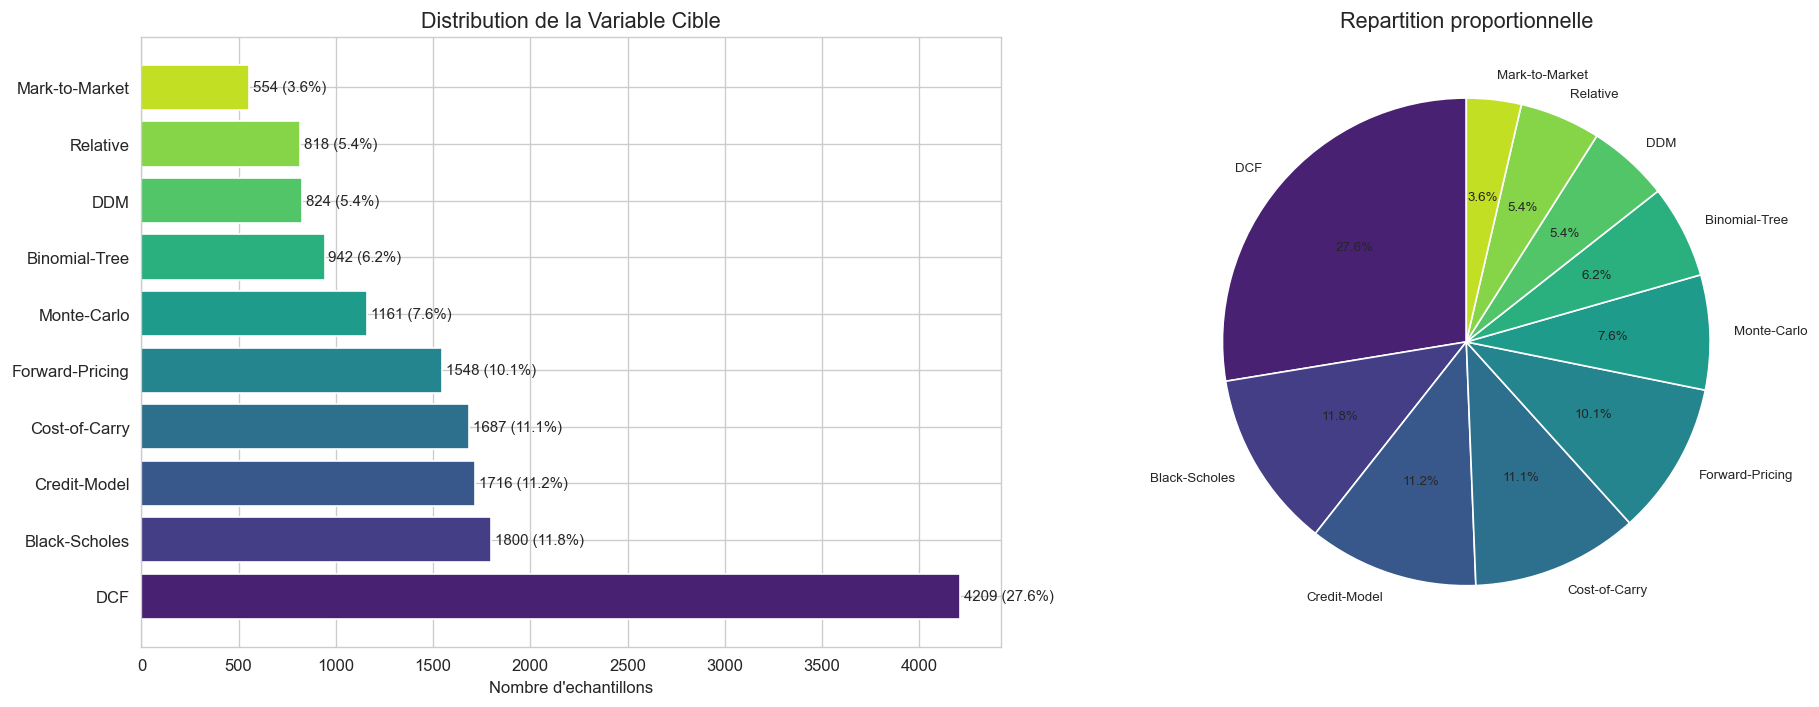

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = df["recommended_method"].value_counts().index
colors = sns.color_palette("viridis", n_colors=len(order))

# Bar
ax = axes[0]
counts = df["recommended_method"].value_counts()[order]
ax.barh(range(len(order)), counts.values, color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("Nombre d'echantillons")
ax.set_title("Distribution de la Variable Cible")
for i, v in enumerate(counts.values):
    ax.text(v + 20, i, f"{v} ({v/len(df)*100:.1f}%)", va="center", fontsize=9)

# Pie
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, textprops={"fontsize": 8})
axes[1].set_title("Repartition proportionnelle")

plt.tight_layout()
plt.savefig(FIG_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Heatmap Asset Class × Méthode


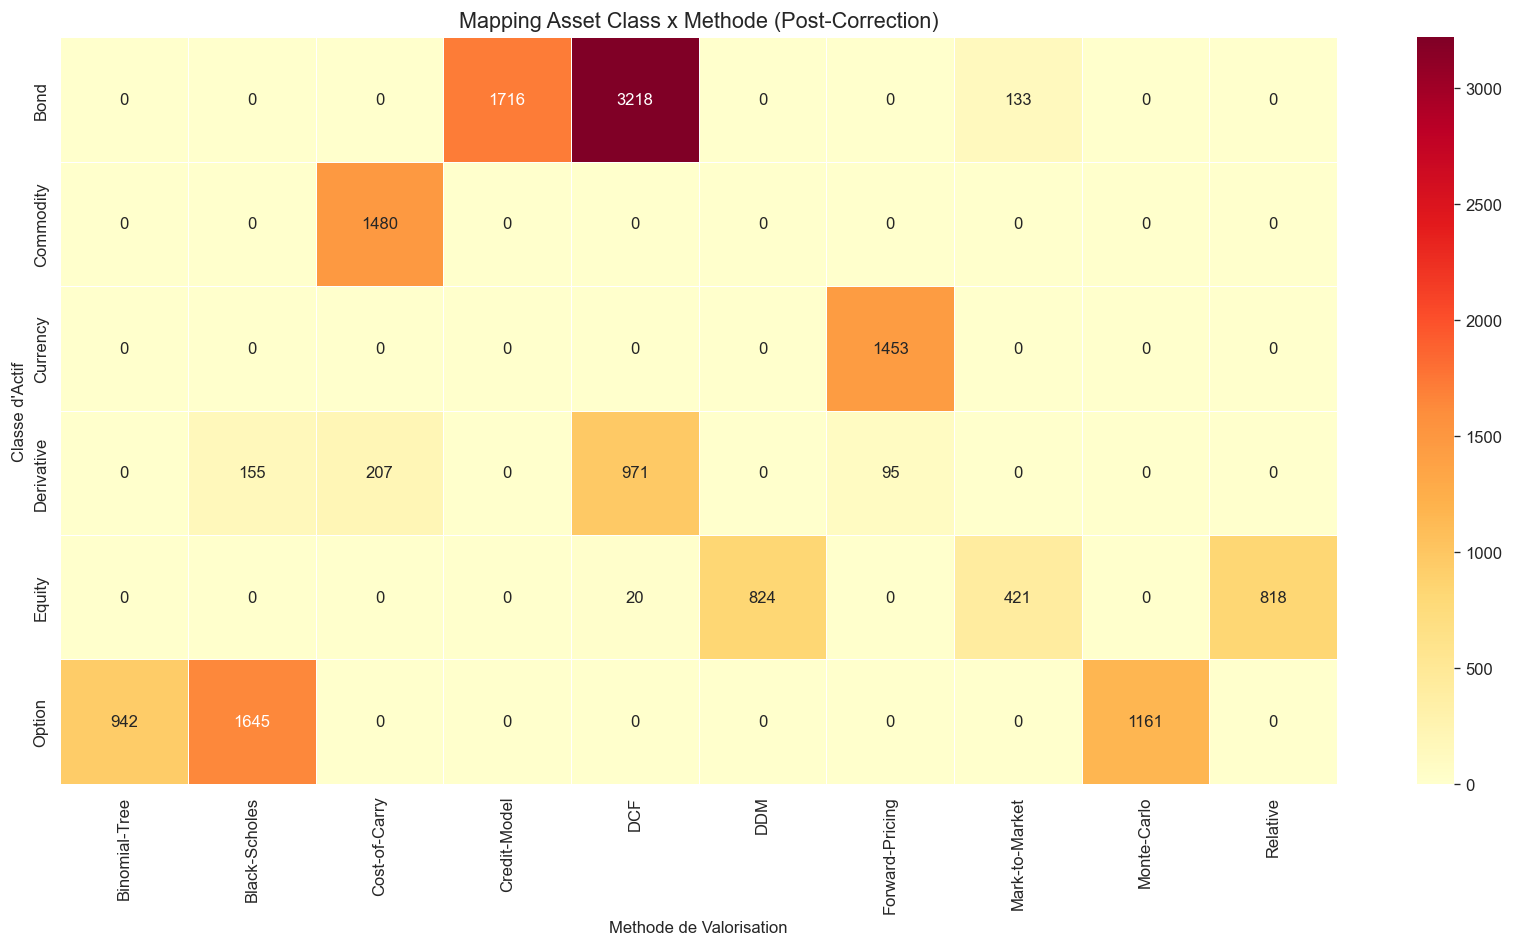

In [5]:
fig, ax = plt.subplots(figsize=(14, 8))
ct = pd.crosstab(df["asset_class"], df["recommended_method"])
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_xlabel("Methode de Valorisation")
ax.set_ylabel("Classe d'Actif")
ax.set_title("Mapping Asset Class x Methode (Post-Correction)")
plt.tight_layout()
plt.savefig(FIG_DIR / "asset_method_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 Features Booléennes par Méthode


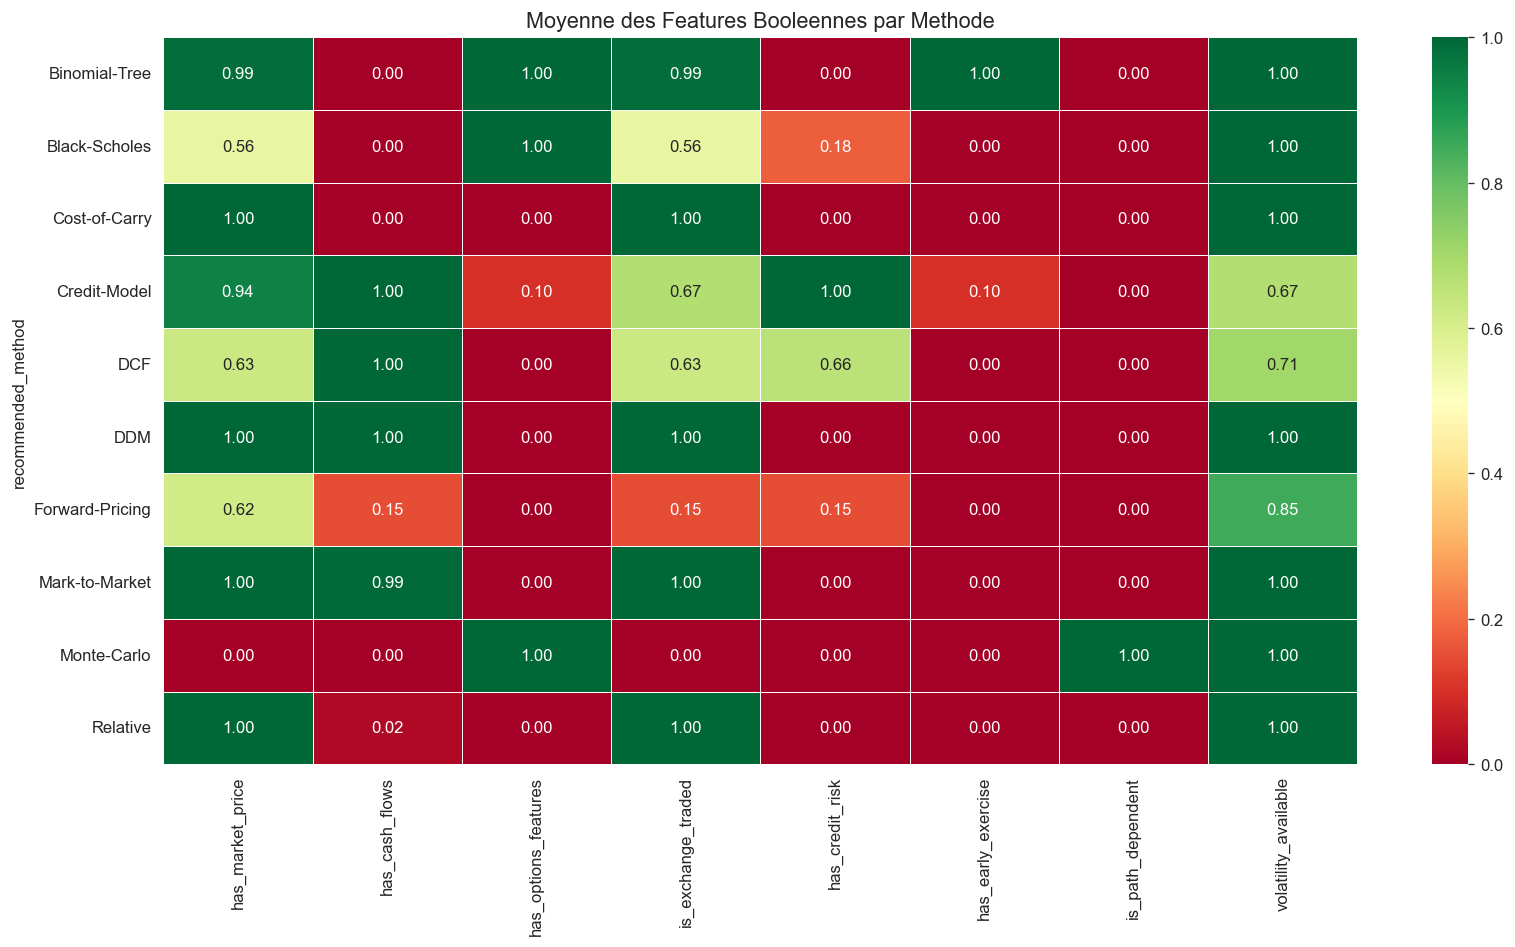

In [6]:
bool_cols = [c for c in ["has_market_price", "has_cash_flows", "has_options_features",
             "is_exchange_traded", "has_credit_risk", "has_early_exercise",
             "is_path_dependent", "volatility_available"] if c in df.columns]

fig, ax = plt.subplots(figsize=(14, 8))
means = df.groupby("recommended_method")[bool_cols].mean()
sns.heatmap(means, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5,
            vmin=0, vmax=1, ax=ax)
ax.set_title("Moyenne des Features Booleennes par Methode")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_heatmap_bool.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4 Maturité, IFRS, Corrélation


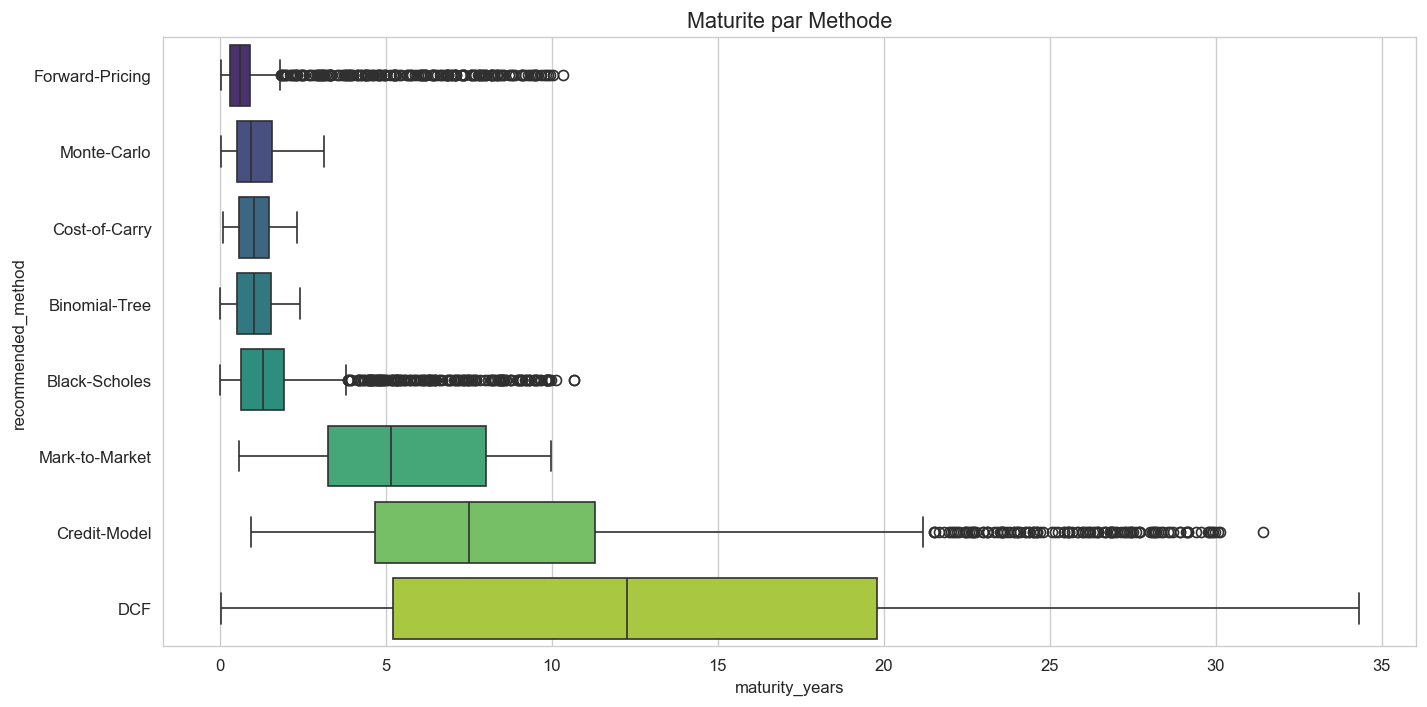

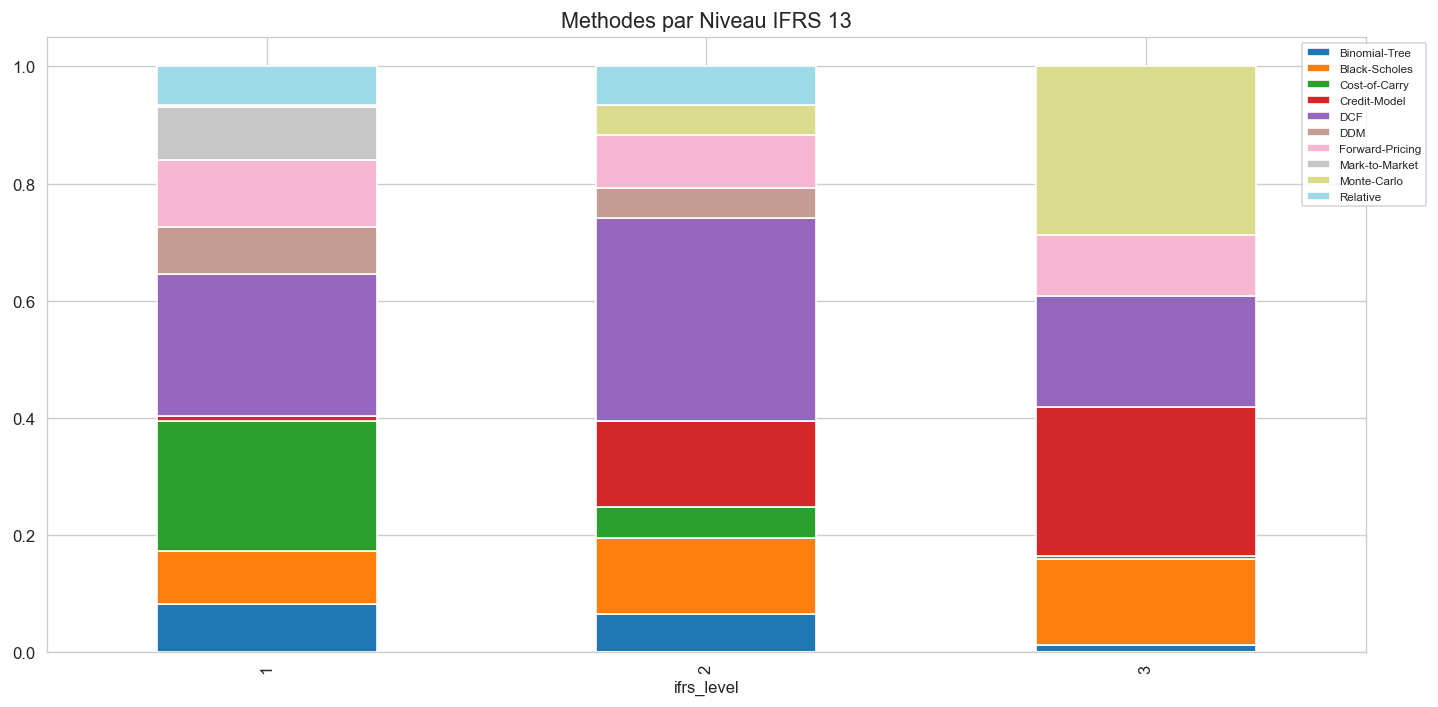

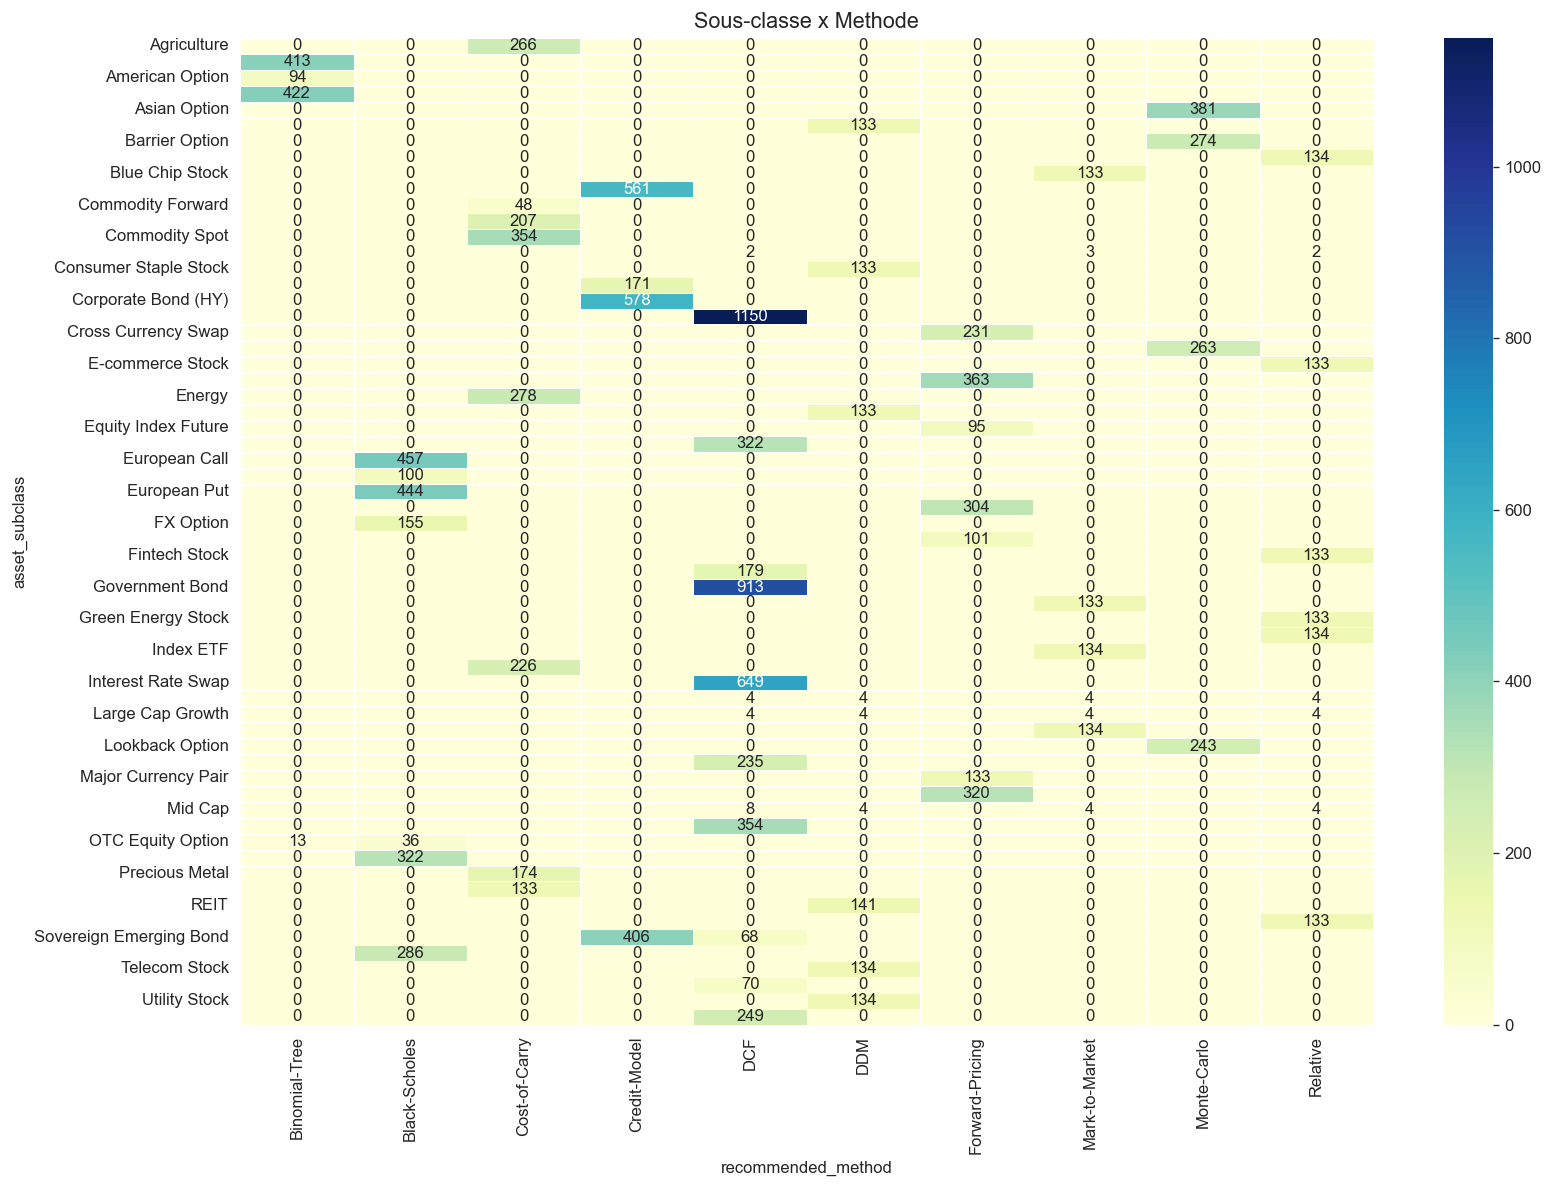

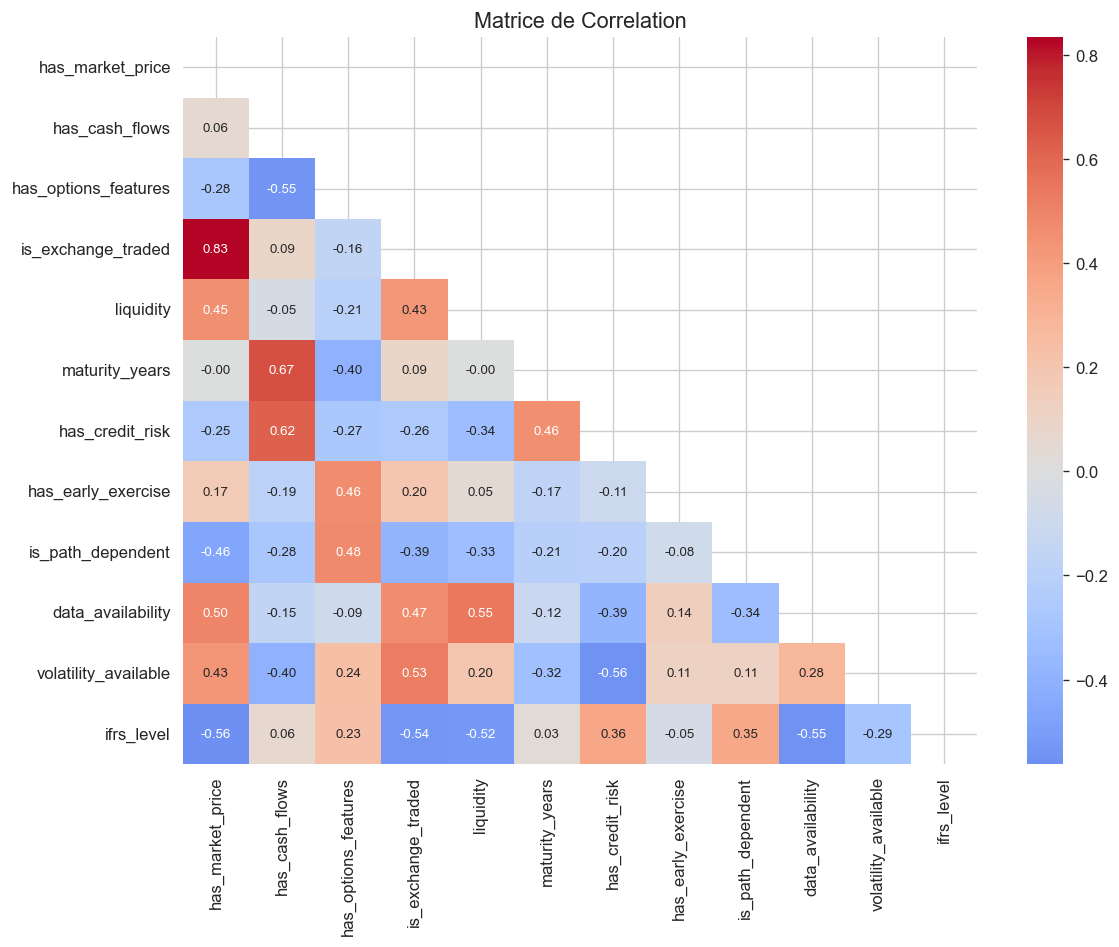

In [7]:
# Maturity
if "maturity_years" in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_data = df[df["maturity_years"].notna()]
    order_box = plot_data.groupby("recommended_method")["maturity_years"].median().sort_values().index
    sns.boxplot(data=plot_data, x="maturity_years", y="recommended_method",
                order=order_box, palette="viridis", ax=ax)
    ax.set_title("Maturite par Methode")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "maturity_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

# IFRS
if "ifrs_level" in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    ct_ifrs = pd.crosstab(df["ifrs_level"], df["recommended_method"], normalize="index")
    ct_ifrs.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_title("Methodes par Niveau IFRS 13")
    ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ifrs_level_methods.png", dpi=150, bbox_inches="tight")
    plt.show()

# Subclass heatmap
if "asset_subclass" in df.columns:
    fig, ax = plt.subplots(figsize=(14, 10))
    ct_sub = pd.crosstab(df["asset_subclass"], df["recommended_method"])
    # Only show subclasses with > 5 samples for readability
    ct_sub = ct_sub[ct_sub.sum(axis=1) > 5]
    sns.heatmap(ct_sub, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.3, ax=ax)
    ax.set_title("Sous-classe x Methode")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "subclass_method_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

# Correlation
df_corr = df.copy()
for col, mapping in {"liquidity": {"Low":0,"Medium":1,"High":2},
                      "data_availability": {"Sparse":0,"Partial":1,"Full":2}}.items():
    if col in df_corr.columns and df_corr[col].dtype == object:
        df_corr[col] = df_corr[col].map(mapping)

num_cols = [c for c in df_corr.select_dtypes(include=[np.number]).columns if c != "recommended_method"]
if len(num_cols) >= 3:
    corr = df_corr[num_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, ax=ax, annot_kws={"size": 8})
    ax.set_title("Matrice de Correlation")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## 4. Ingénierie des Features

### Stratégie d'enrichissement
On ajoute des features numériques réelles depuis les données brutes collectées.
Les features sont groupées par classe d'actif — chaque ligne reçoit des valeurs
cohérentes avec sa `asset_class`.


In [8]:
def safe_read(path):
    """Charge un fichier parquet/csv avec gestion d'erreur."""
    try:
        if path.suffix == ".parquet":
            return pd.read_parquet(path)
        else:
            return pd.read_csv(path)
    except Exception as e:
        print(f"  ✗ Erreur chargement {path.name}: {e}")
        return None

def enrich_dataset(df):
    """
    Enrichit le dataset avec 6 groupes de features numeriques.
    Chaque groupe cible une classe d'actif specifique.
    """
    enriched = df.copy()
    np.random.seed(42)
    n = len(enriched)
    added_features = []
    
    # ══════════════════════════════════════════════════════════
    # GROUPE A — Features de taux (FRED) — globales
    # ══════════════════════════════════════════════════════════
    yc_data = safe_read(RAW / "macro/fred_treasury_yields.parquet")
    cs_data = safe_read(RAW / "macro/fred_credit_spreads.parquet")
    
    if yc_data is not None:
        latest = yc_data.iloc[-1]
        # Chercher les bonnes colonnes (noms variables selon la source FRED)
        r3m = r2y = r5y = r10y = np.nan
        for col in yc_data.columns:
            cl = col.upper()
            if "3MO" in cl or "3M" in cl: r3m = latest[col]
            elif cl in ["DGS2", "GS2"] or ("2Y" in cl and "10" not in cl): r2y = latest[col]
            elif cl in ["DGS5", "GS5"] or "5Y" in cl: r5y = latest[col]
            elif cl in ["DGS10", "GS10"] or "10Y" in cl: r10y = latest[col]
        
        if pd.notna(r3m):
            enriched["risk_free_rate_3m"] = r3m * (1 + np.random.normal(0, 0.005, n))
            added_features.append("risk_free_rate_3m")
        if pd.notna(r10y):
            enriched["yield_10y"] = r10y * (1 + np.random.normal(0, 0.005, n))
            added_features.append("yield_10y")
        if pd.notna(r10y) and pd.notna(r2y):
            enriched["yield_curve_slope"] = (r10y - r2y) + np.random.normal(0, 0.02, n)
            added_features.append("yield_curve_slope")
    
    if cs_data is not None:
        latest_cs = cs_data.iloc[-1]
        # Baa-Aaa spread
        baa_col = aaa_col = None
        for col in cs_data.columns:
            if col.upper() in ["BAA", "DBAA"]: baa_col = col
            elif col.upper() in ["AAA", "DAAA"]: aaa_col = col
        if baa_col and aaa_col and pd.notna(latest_cs[baa_col]) and pd.notna(latest_cs[aaa_col]):
            spread = latest_cs[baa_col] - latest_cs[aaa_col]
            enriched["baa_aaa_spread"] = spread + np.random.normal(0, 0.01, n)
            added_features.append("baa_aaa_spread")
    
    print(f"  [A] Taux : {added_features}")
    
    # ══════════════════════════════════════════════════════════
    # GROUPE B — Volatilite (equity prices)
    # ══════════════════════════════════════════════════════════
    eq_prices = safe_read(RAW / "equities/equity_historical_prices.parquet")
    vol_added = []
    
    if eq_prices is not None and "Close" in eq_prices.columns:
        # Calculer vol a partir de toutes les donnees disponibles
        try:
            if "symbol" in eq_prices.columns:
                # Multi-ticker
                vol_by_ticker = {}
                for ticker in eq_prices["symbol"].unique():
                    sub = eq_prices[eq_prices["symbol"] == ticker]["Close"].dropna()
                    if len(sub) >= 30:
                        lr = np.log(sub / sub.shift(1)).dropna()
                        vol_by_ticker[ticker] = lr.tail(30).std() * np.sqrt(252)
                real_vols = np.array(list(vol_by_ticker.values()))
                real_vols = real_vols[np.isfinite(real_vols) & (real_vols > 0)]
            else:
                # Single series
                close = eq_prices["Close"].dropna()
                lr = np.log(close / close.shift(1)).dropna()
                real_vols = np.array([lr.tail(30).std() * np.sqrt(252)])
            
            if len(real_vols) > 0:
                for ac in ["Equity", "Option"]:
                    mask = enriched["asset_class"] == ac
                    if mask.sum() > 0:
                        enriched.loc[mask, "historical_vol_30d"] = np.random.choice(
                            real_vols, size=mask.sum(), replace=True)
                vol_added.append("historical_vol_30d")
        except Exception as e:
            print(f"  ✗ Erreur calcul volatilite: {e}")
    
    print(f"  [B] Volatilite : {vol_added if vol_added else 'non disponible (fichier corrompu)'}")
    added_features.extend(vol_added)
    
    # ══════════════════════════════════════════════════════════
    # GROUPE C — Options features
    # ══════════════════════════════════════════════════════════
    opt_data = safe_read(RAW / "options/options_chains_full.parquet")
    opt_added = []
    
    if opt_data is not None:
        iv_col = next((c for c in opt_data.columns if "implied" in c.lower() and "vol" in c.lower()), None)
        if iv_col:
            iv_valid = opt_data[iv_col].dropna()
            iv_valid = iv_valid[iv_valid > 0].values
            if len(iv_valid) > 0:
                opt_mask = enriched["asset_class"] == "Option"
                if opt_mask.sum() > 0:
                    enriched.loc[opt_mask, "implied_volatility_atm"] = np.random.choice(
                        iv_valid, size=opt_mask.sum(), replace=True)
                    opt_added.append("implied_volatility_atm")
        
        # IV skew
        if "moneyness" in opt_data.columns and iv_col:
            otm = opt_data[opt_data["moneyness"].between(0.85, 0.95)][iv_col].dropna()
            atm = opt_data[opt_data["moneyness"].between(0.95, 1.05)][iv_col].dropna()
            if len(otm) > 0 and len(atm) > 0:
                skew_val = otm.median() - atm.median()
                opt_mask = enriched["asset_class"] == "Option"
                if opt_mask.sum() > 0:
                    enriched.loc[opt_mask, "iv_skew"] = skew_val + np.random.normal(0, 0.01, opt_mask.sum())
                    opt_added.append("iv_skew")
    
    print(f"  [C] Options : {opt_added if opt_added else 'non disponible'}")
    added_features.extend(opt_added)
    
    # ══════════════════════════════════════════════════════════
    # GROUPE D — Equity fundamentals
    # ══════════════════════════════════════════════════════════
    fund_data = safe_read(RAW / "equities/equity_fundamentals.parquet")
    fund_added = []
    
    if fund_data is not None:
        eq_mask = enriched["asset_class"] == "Equity"
        n_eq = eq_mask.sum()
        if n_eq > 0:
            for col in ["beta", "pe_ratio", "dividend_yield", "market_cap", "debt_to_equity"]:
                # Try various column name conventions
                src = None
                for candidate in [col, col.replace("_",""), col.title().replace("_",""),
                                  col.upper(), col.lower()]:
                    if candidate in fund_data.columns:
                        src = candidate
                        break
                
                if src:
                    vals = fund_data[src].dropna().values
                    vals = vals[np.isfinite(vals)]
                    if len(vals) > 0:
                        sampled = np.random.choice(vals, size=n_eq, replace=True)
                        enriched.loc[eq_mask, col] = sampled * (1 + np.random.normal(0, 0.02, n_eq))
                        fund_added.append(col)
    
    print(f"  [D] Fondamentaux : {fund_added if fund_added else 'non disponible'}")
    added_features.extend(fund_added)
    
    # ══════════════════════════════════════════════════════════
    # GROUPE E — Bond-specifiques
    # ══════════════════════════════════════════════════════════
    bond_mask = enriched["asset_class"] == "Bond"
    n_bond = bond_mask.sum()
    bond_added = []
    if n_bond > 0:
        mat = enriched.loc[bond_mask, "maturity_years"].fillna(10)
        enriched.loc[bond_mask, "duration_estimate"] = mat * np.random.uniform(0.75, 0.95, n_bond)
        bond_added.append("duration_estimate")
        
        has_cr = bond_mask & (enriched["has_credit_risk"] == 1)
        no_cr  = bond_mask & (enriched["has_credit_risk"] == 0)
        enriched.loc[has_cr, "credit_spread_asset"] = np.random.uniform(1.0, 5.0, has_cr.sum())
        enriched.loc[no_cr, "credit_spread_asset"]  = np.random.uniform(0.0, 0.5, no_cr.sum())
        bond_added.append("credit_spread_asset")
    
    print(f"  [E] Bond : {bond_added}")
    added_features.extend(bond_added)
    
    # ══════════════════════════════════════════════════════════
    # GROUPE F — Commodity-specifiques
    # ══════════════════════════════════════════════════════════
    comm_mask = enriched["asset_class"] == "Commodity"
    comm_added = []
    if comm_mask.sum() > 0:
        enriched.loc[comm_mask, "convenience_yield"] = np.random.uniform(0.01, 0.08, comm_mask.sum())
        enriched.loc[comm_mask, "storage_cost_pct"]  = np.random.uniform(0.005, 0.03, comm_mask.sum())
        comm_added = ["convenience_yield", "storage_cost_pct"]
    
    print(f"  [F] Commodity : {comm_added}")
    added_features.extend(comm_added)
    
    new_cols = [c for c in enriched.columns if c not in df.columns]
    print(f"\n  Total features ajoutees : {len(new_cols)} ({new_cols})")
    print(f"  Shape enrichi : {enriched.shape}")
    
    return enriched

print("enrich_dataset() definie")

enrich_dataset() definie


In [9]:
# ── Executer l'enrichissement ──────────────────────────────────
print("=" * 60)
print("  ENRICHISSEMENT DU DATASET")
print("=" * 60)
df_enriched = enrich_dataset(df)

  ENRICHISSEMENT DU DATASET
  [A] Taux : ['risk_free_rate_3m', 'yield_10y', 'yield_curve_slope']
  ✗ Erreur chargement equity_historical_prices.parquet: 'kind'
  [B] Volatilite : non disponible (fichier corrompu)
  [C] Options : ['implied_volatility_atm', 'iv_skew']
  [D] Fondamentaux : ['beta', 'pe_ratio', 'dividend_yield', 'market_cap', 'debt_to_equity']
  [E] Bond : ['duration_estimate', 'credit_spread_asset']
  [F] Commodity : ['convenience_yield', 'storage_cost_pct']

  Total features ajoutees : 14 (['risk_free_rate_3m', 'yield_10y', 'yield_curve_slope', 'implied_volatility_atm', 'iv_skew', 'beta', 'pe_ratio', 'dividend_yield', 'market_cap', 'debt_to_equity', 'duration_estimate', 'credit_spread_asset', 'convenience_yield', 'storage_cost_pct'])
  Shape enrichi : (15259, 29)


---
## 5. Encodage + Nettoyage des Valeurs Manquantes


In [10]:
# ══════════════════════════════════════════════════════════════
# 5.1 — Encodage
# ══════════════════════════════════════════════════════════════
df_enc = df_enriched.copy()
label_encoders = {}

# Ordinales
for col, mapping in {"liquidity": {"Low":0,"Medium":1,"High":2},
                      "data_availability": {"Sparse":0,"Partial":1,"Full":2}}.items():
    if col in df_enc.columns and df_enc[col].dtype == object:
        df_enc[col] = df_enc[col].map(mapping)
        unmapped = df_enc[col].isna().sum()
        if unmapped > 0:
            df_enc[col] = df_enc[col].fillna(1)  # Medium/Partial as default
            print(f"  {col} : {unmapped} valeurs non mappees -> defaut=1")
        print(f"  {col} encode")

# Nominales
for col in ["asset_class", "asset_subclass"]:
    if col in df_enc.columns:
        le = LabelEncoder()
        df_enc[col + "_encoded"] = le.fit_transform(df_enc[col].astype(str))
        label_encoders[col] = le
        print(f"  {col} -> {col}_encoded ({len(le.classes_)} classes)")

# ══════════════════════════════════════════════════════════════
# 5.2 — Nettoyage des valeurs manquantes (domain-aware)
# ══════════════════════════════════════════════════════════════
print(f"\nNaN avant nettoyage : {df_enc.select_dtypes(include=[np.number]).isna().sum().sum()}")

# Maturity NaN = perpetuel → sentinelle -1
if "maturity_years" in df_enc.columns:
    n_perp = df_enc["maturity_years"].isna().sum()
    df_enc["maturity_years"] = df_enc["maturity_years"].fillna(-1)
    if n_perp > 0:
        print(f"  maturity_years : {n_perp} NaN -> -1 (perpetuels)")

# Features specifiques : 0 pour les classes d'actif non-concernees
fill_zero_rules = {
    "Option":    ["implied_volatility_atm", "iv_skew"],
    "Bond":      ["duration_estimate", "credit_spread_asset"],
    "Commodity": ["convenience_yield", "storage_cost_pct"],
    "Equity":    ["beta", "pe_ratio", "dividend_yield", "market_cap", "debt_to_equity"],
}

for target_class, feat_cols in fill_zero_rules.items():
    non_target = df_enc["asset_class"] != target_class
    for col in feat_cols:
        if col in df_enc.columns:
            df_enc.loc[non_target, col] = df_enc.loc[non_target, col].fillna(0)

# Volatilite : 0 pour les classes sans historique
if "historical_vol_30d" in df_enc.columns:
    for cls in ["Bond", "Commodity", "Currency", "Derivative"]:
        mask = df_enc["asset_class"] == cls
        df_enc.loc[mask, "historical_vol_30d"] = df_enc.loc[mask, "historical_vol_30d"].fillna(0)

# Mediane pour tout le reste
num_cols = df_enc.select_dtypes(include=[np.number]).columns
n_median = 0
for col in num_cols:
    n_null = df_enc[col].isna().sum()
    if n_null > 0:
        df_enc[col] = df_enc[col].fillna(df_enc[col].median())
        n_median += n_null

# Infinis
df_enc = df_enc.replace([np.inf, -np.inf], np.nan)
for col in num_cols:
    if df_enc[col].isna().sum() > 0:
        df_enc[col] = df_enc[col].fillna(df_enc[col].median())

remaining = df_enc.select_dtypes(include=[np.number]).isna().sum().sum()
print(f"  Imputation mediane : {n_median} valeurs")
print(f"  NaN restants : {remaining}")

if remaining > 0:
    # Nuclear option — colonnes encore problematiques
    problem_cols = df_enc.columns[df_enc.isna().any()].tolist()
    print(f"  Colonnes problematiques : {problem_cols}")
    df_enc = df_enc.fillna(0)
    print(f"  Remplissage final par 0 — NaN restants : {df_enc.isna().sum().sum()}")

  liquidity encode
  data_availability encode
  asset_class -> asset_class_encoded (6 classes)
  asset_subclass -> asset_subclass_encoded (71 classes)

NaN avant nettoyage : 139195
  maturity_years : 2351 NaN -> -1 (perpetuels)
  Imputation mediane : 0 valeurs
  NaN restants : 0


---
## 6. Construction X/y, Split et Sauvegarde


In [11]:
# ── Construire X et y ──────────────────────────────────────────
target_col = "recommended_method"

drop_cols = [target_col, "asset_class", "asset_subclass"]
X = df_enc.drop(columns=[c for c in drop_cols if c in df_enc.columns])
X = X.select_dtypes(include=[np.number])

le_target = LabelEncoder()
y = pd.Series(le_target.fit_transform(df_enc[target_col]),
              index=df_enc.index, name=target_col)

print(f"X : {X.shape}")
print(f"y : {y.shape} ({len(le_target.classes_)} classes)")
print(f"Features : {list(X.columns)}")
print(f"NaN : {X.isna().sum().sum()}")

# ── Split 80/20 stratifie ─────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.0f}%)")

print(f"\nDistribution train :")
for cls_idx in sorted(y_train.unique()):
    cls_name = le_target.inverse_transform([cls_idx])[0]
    cnt = (y_train == cls_idx).sum()
    print(f"  {cls_name:20s} : {cnt:5d}")

print(f"\nDistribution val :")
for cls_idx in sorted(y_val.unique()):
    cls_name = le_target.inverse_transform([cls_idx])[0]
    cnt = (y_val == cls_idx).sum()
    flag = " ⚠️" if cnt < 20 else ""
    print(f"  {cls_name:20s} : {cnt:5d}{flag}")

# Verifier qu'aucune classe n'a < 10 dans le val set
min_val = min((y_val == i).sum() for i in range(len(le_target.classes_)))
if min_val < 10:
    print(f"\n⚠️  La classe la plus petite a {min_val} echantillons en val — risque de metriques instables")
else:
    print(f"\n✅ Toutes les classes ont >= {min_val} echantillons en val")

X : (15259, 28)
y : (15259,) (10 classes)
Features : ['has_market_price', 'has_cash_flows', 'has_options_features', 'is_exchange_traded', 'liquidity', 'maturity_years', 'has_credit_risk', 'has_early_exercise', 'is_path_dependent', 'data_availability', 'volatility_available', 'ifrs_level', 'risk_free_rate_3m', 'yield_10y', 'yield_curve_slope', 'implied_volatility_atm', 'iv_skew', 'beta', 'pe_ratio', 'dividend_yield', 'market_cap', 'debt_to_equity', 'duration_estimate', 'credit_spread_asset', 'convenience_yield', 'storage_cost_pct', 'asset_class_encoded', 'asset_subclass_encoded']
NaN : 0

Train : 12207 (80%)
Val   : 3052 (20%)

Distribution train :
  Binomial-Tree        :   754
  Black-Scholes        :  1440
  Cost-of-Carry        :  1350
  Credit-Model         :  1373
  DCF                  :  3367
  DDM                  :   659
  Forward-Pricing      :  1238
  Mark-to-Market       :   443
  Monte-Carlo          :   929
  Relative             :   654

Distribution val :
  Binomial-Tre

In [12]:
# ── Sauvegarder ───────────────────────────────────────────────
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Matrices
joblib.dump(X_train, models_dir / "X_train.pkl")
joblib.dump(y_train, models_dir / "y_train.pkl")
joblib.dump(X_val,   models_dir / "X_val.pkl")
joblib.dump(y_val,   models_dir / "y_val.pkl")

# Encoders
joblib.dump(le_target,      models_dir / "label_encoder_target.pkl")
joblib.dump(label_encoders, models_dir / "feature_label_encoders.pkl")

# Dataset complet
df_enc.to_parquet(PROCESSED / "features_final.parquet", index=False)
df_enc.to_csv(PROCESSED / "features_final.csv", index=False)

# Aussi sauvegarder le dataset balanced corrige (sans enrichissement)
df.to_csv(PROCESSED / "labeled_valuation_dataset_balanced.csv", index=False)

print("Fichiers sauvegardes :")
for f in [
    models_dir / "X_train.pkl", models_dir / "y_train.pkl",
    models_dir / "X_val.pkl", models_dir / "y_val.pkl",
    models_dir / "label_encoder_target.pkl",
    PROCESSED / "features_final.parquet",
]:
    print(f"  {f}")

Fichiers sauvegardes :
  models\X_train.pkl
  models\y_train.pkl
  models\X_val.pkl
  models\y_val.pkl
  models\label_encoder_target.pkl
  data_valuation_project\processed\features_final.parquet


---
## 7. Health Check Final


In [13]:
from sklearn.utils.class_weight import compute_class_weight

print("=" * 60)
print("  VALUSENSE — HEALTH CHECK FINAL")
print("=" * 60)

print(f"\n  Dataset source          : {source_name}")
print(f"  Total echantillons      : {len(df_enc):,}")
print(f"  Features (X)            : {X.shape[1]}")
print(f"  Classes cibles          : {len(le_target.classes_)}")

# Imbalance
counts_y = pd.Series(y).value_counts()
ratio = counts_y.max() / counts_y.min()
print(f"  Ratio d'imbalance       : {ratio:.1f}:1")

# NaN check
train_nan = X_train.isna().sum().sum()
val_nan   = X_val.isna().sum().sum()
print(f"\n  NaN train               : {train_nan}")
print(f"  NaN val                 : {val_nan}")
if train_nan == 0 and val_nan == 0:
    print("  ✅ Aucune valeur manquante")
else:
    print("  ⚠️  Valeurs manquantes restantes !")

# Class weights
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
weight_dict = dict(zip(classes, weights))

print(f"\n  Class weights (pour le training) :")
max_weight = max(weights)
for cls_idx in sorted(weight_dict.keys()):
    w = weight_dict[cls_idx]
    cls_name = le_target.inverse_transform([cls_idx])[0]
    bar = "█" * int(w / max_weight * 20)
    flag = " ⚠️ EXTREME" if w > 10 else ""
    print(f"    {cls_name:20s} : {w:6.2f}x {bar}{flag}")

if max_weight > 10:
    print("\n  ⚠️  Poids > 10x detecte — les classes sous-representees vont dominer le gradient")
    print("     Verifier que labeled_valuation_dataset_balanced.csv a bien ete charge")
else:
    print("\n  ✅ Poids raisonnables — pret pour le training")

# Domain check
print(f"\n  Violations domaine      : {'0 ✅' if not violations else len(violations)}")

print(f"""
  ══════════════════════════════════════════════════
  PROCHAINE ETAPE : 04_model_training.ipynb
  ══════════════════════════════════════════════════
  
  Strategie recommandee :
  1. Random Forest baseline (class_weight='balanced')
  2. XGBoost primary (sample_weight via compute_sample_weight)
  3. CatBoost comparison (auto_class_weights='Balanced')
  4. RandomizedSearchCV sur le meilleur (50 iterations)
  5. Evaluation : F1 par classe, confusion matrix, Cohen's Kappa
  6. IFRS 13 post-processing (6 regles)
  7. SHAP explainability
""")

  VALUSENSE — HEALTH CHECK FINAL

  Dataset source          : Balanced (post-regeneration)
  Total echantillons      : 15,259
  Features (X)            : 28
  Classes cibles          : 10
  Ratio d'imbalance       : 7.6:1

  NaN train               : 0
  NaN val                 : 0
  ✅ Aucune valeur manquante

  Class weights (pour le training) :
    Binomial-Tree        :   1.62x ███████████
    Black-Scholes        :   0.85x ██████
    Cost-of-Carry        :   0.90x ██████
    Credit-Model         :   0.89x ██████
    DCF                  :   0.36x ██
    DDM                  :   1.85x █████████████
    Forward-Pricing      :   0.99x ███████
    Mark-to-Market       :   2.76x ████████████████████
    Monte-Carlo          :   1.31x █████████
    Relative             :   1.87x █████████████

  ✅ Poids raisonnables — pret pour le training

  Violations domaine      : 0 ✅

  ══════════════════════════════════════════════════
  PROCHAINE ETAPE : 04_model_training.ipynb
  ═════════════════